In [1]:
# model architecture modified from https://keras.io/examples/vision/mnist_convnet/

In [2]:
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Lambda, Softmax, Dense
from tensorflow.keras import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# Convert y_train into one-hot format
temp = []
for i in range(len(y_train)):
    temp.append(to_categorical(y_train[i], num_classes=10))
y_train = np.array(temp)
# Convert y_test into one-hot format
temp = []
for i in range(len(y_test)):    
    temp.append(to_categorical(y_test[i], num_classes=10))
y_test = np.array(temp)

In [5]:
#reshaping
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

In [8]:
inputs = Input(shape=(28,28,1))
out = Lambda(lambda x: x/1000)(inputs)
out = Conv2D(4, 3)(out)
out = Lambda(lambda x: x**2+x)(out)
out = AveragePooling2D(1)(out)
out = Lambda(lambda x: x*4)(out)
out = Conv2D(8, 3)(out)
out = Lambda(lambda x: x**2+x)(out)
out = AveragePooling2D(1)(out)
out = Lambda(lambda x: x*4)(out)
out = Flatten()(out)
out = Dense(10, activation=None)(out)
out = Softmax()(out)
full_model = Model(inputs, out)

In [9]:
full_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_6 (Lambda)               │ (None, 26, 26, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 26, 26, 4)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_7 (Lambda)               │ (None, 26, 26, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_8 (Lambda)               │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 24, 24, 8)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_9 (Lambda)               │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        46,090 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,426 (181.35 KB)

 Trainable params: 46,426 (181.35 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
full_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
    )

In [11]:
full_model.fit(X_train, y_train, epochs=15, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9424 - loss: 0.1884 - val_acc: 0.9748 - val_loss: 0.0800
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9776 - loss: 0.0742 - val_acc: 0.9766 - val_loss: 0.0751
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9827 - loss: 0.0545 - val_acc: 0.9789 - val_loss: 0.0721
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9861 - loss: 0.0447 - val_acc: 0.9772 - val_loss: 0.0731
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9879 - loss: 0.0374 - val_acc: 0.9797 - val_loss: 0.0708
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9898 - loss: 0.0311 - val_acc: 0.9785 - val_loss: 0.0691
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9916 - loss: 0.0249 - val_acc: 0.9809 - val_loss: 0.0737
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9933 - loss: 0.0211 - val_acc: 0.9811 - val_loss: 0.0749
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - ac

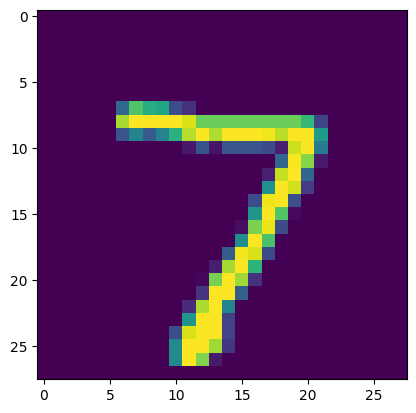

In [16]:
X = X_test[[0]]
plt.imshow(X[0])

In [17]:
model = Model(full_model.input, full_model.layers[-2].output)

In [18]:
y = model.predict(X) - model.weights[5].numpy()
y

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[ -7.0456157,   1.8796574,   4.6819186,  10.586745 , -27.15753  ,
        -13.141556 , -44.748676 ,  37.465733 ,  -2.0173502,   4.118524 ]],
      dtype=float32)

In [19]:
print(len(model.weights))
for weights in model.weights:
    print(weights.shape)

6
(3, 3, 1, 4)
(4,)
(3, 3, 4, 8)
(8,)
(4608, 10)
(10,)


In [36]:
in_json = {
    "in": X[0].astype(int).astype(str).tolist(), # X is already 1000 times to begin with
    "conv2d_1_weights": (model.weights[0].numpy()*(10**3)).round().astype(int).astype(str).tolist(),
    "conv2d_1_bias": (model.weights[1].numpy()*(10**3)*(10**3)).round().astype(int).astype(str).tolist(),
    # poly layer would be (10**3)**2=10**6 times as well
    "conv2d_2_weights": (model.weights[2].numpy()*(10**3)).round().astype(int).astype(str).tolist(),
    "conv2d_2_bias": (model.weights[3].numpy()*((10**3)**5)).round().astype(int).astype(str).tolist(),
    # poly layer would be (10**3)**5=10**15 times as well
    "dense_weights":(model.weights[4].numpy()*(10**3)).round().astype(int).astype(str).tolist(),
    "dense_bias": np.zeros(model.weights[5].numpy().shape).astype(int).astype(str).tolist() # zero because we are not doing softmax in circom, just argmax
}
in_json['dense_weights'] = in_json['dense_weights'][0:200]

In [37]:
out_json = {
    "scale": 10**-33,
    "out": y.flatten().tolist(),
    "label": int(y_test[0].argmax())
}
out_json

{'scale': 1e-33,
 'out': [-7.0456156730651855,
  1.8796573877334595,
  4.681918621063232,
  10.586745262145996,
  -27.157529830932617,
  -13.141555786132812,
  -44.74867630004883,
  37.46573257446289,
  -2.017350196838379,
  4.118524074554443],
 'label': 7}

In [38]:
import json

In [39]:
with open("mnist_convnet_input.json", "w") as f:
    json.dump(in_json, f)

In [40]:
with open("mnist_convnet_output.json", "w") as f:
    json.dump(out_json, f)